In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import os
import pickle
import pandas as pd
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

from picasso import Picasso, CloneTree
from Bio import Phylo
from io import StringIO

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir



In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata, min_counts=0, min_p=0)

In [3]:
### find which variants can be confidently called as heterozygous vs only mutated (het+homozygous) vs wt (homozygous)

p_allow_heterozygotes = 0
p_disallow_heterozygotes = 0

variant_df = adata.obsm['genotype_call'].loc[:,(adata.obsm['genotype_call'].notna() & (adata.obsm['genotype_call'] != 'wt')).sum() > 0]
for mutation in variant_df.columns:
    mask_1 = adata.obsm['genotypes'][[mutation + '_mutated', mutation + '_wt', mutation + '_heterozygous']].max(axis=1) > p_allow_heterozygotes
    mask_2 = adata.obsm['genotypes'][[mutation + '_mutated', mutation + '_wt', mutation + '_heterozygous']].max(axis=1) > p_disallow_heterozygotes
    if (mask_1 == True).sum() > 3000:
        variant_df.loc[~mask_1, mutation] = None
        variant_df.loc[:,mutation] = variant_df[mutation].replace({'mutated': 2, 'wt': 0, 'heterozygous': 1})
    elif (mask_2 == True).sum() > 3000:
        variant_df.loc[~mask_2, mutation] = None
        variant_df.loc[:,mutation] = variant_df[mutation].replace({'mutated': 2, 'wt': 0, 'heterozygous': 2})
    else:
        variant_df = variant_df.drop(columns=[mutation])

variant_df = variant_df.drop('NRAS c.35G>A', axis=1) ### remove NRAS to help resolution for the dominant 4 variants; then we add NRAS later
data = variant_df.dropna().astype(int)
print(len(data))

1349


Initialized CloneTree with 8 clones and 1349 samples.


maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 35 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'G', 'H', 'L', 'P', 'R', 'S', 'T', 'Z', 'c', 'd', 'e', 'eight', 'five', 'four', 'greater', 'hyphen', 'i', 'l', 'less', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 's', 'space', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 27, 31, 33, 36, 38, 40, 42, 43, 47, 51, 53, 54, 55, 61, 66, 70, 71, 72, 76, 79, 81, 82, 86]
Closed glyph list over 'MATH': 35 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'G', 'H', 'L', 'P', 'R', 'S', 'T', 'Z', 'c', 'd', 'e', 'eight', 'five', 'four', 'greater', 'hyphen', 'i', 'l', 'less', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 's', 'space', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 27, 31, 3

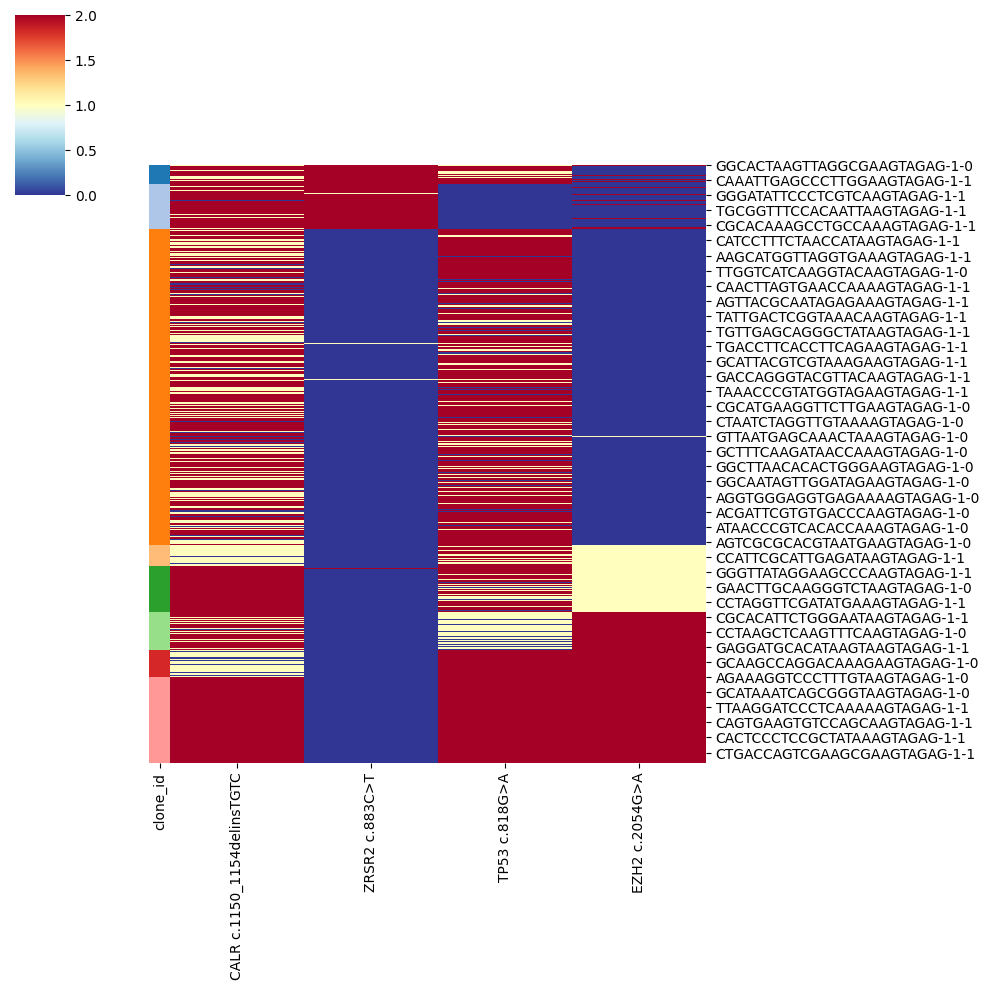

In [4]:
### run picasso, output is not deterministic so load in the saved output 

filename = '../data/unfiltered_picasso_model.pkl'

if os.path.exists(filename):
    model = pickle.load(open(filename, 'rb'))
else:
    model = Picasso(
        data,
        min_clone_size=40,
        max_depth=6,
        terminate_by='probability'
    )
    # --- Run model ---
    model.fit()
    
# Check if file already exists
if not os.path.exists(filename):
    # Save the trained Picasso model
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print("Model saved as " + filename)

phylogeny = model.get_phylogeny()
assignments = model.get_clone_assignments()

clone_tree = CloneTree(phylogeny, assignments, data)
clone_tree.plot_alterations(cmap='RdYlBu_r', save_as='../plots/unfiltered_picasso_clone_tree.pdf')